In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df = pd.read_csv('../data/superstore_sales.csv', encoding='latin1')

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Year and Month columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10


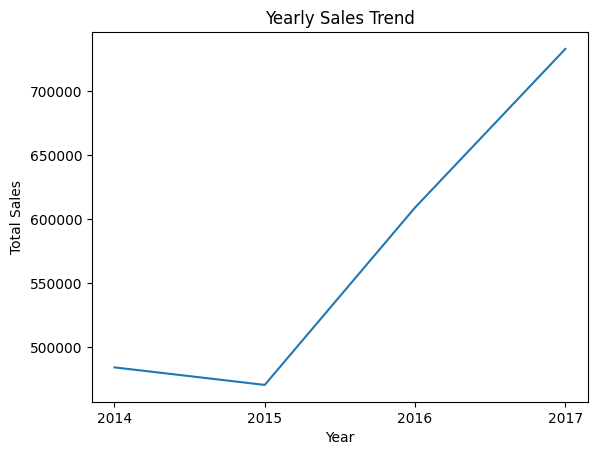

In [3]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure()
plt.plot(yearly_sales['Year'], yearly_sales['Sales'])
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(yearly_sales['Year'])
plt.show()


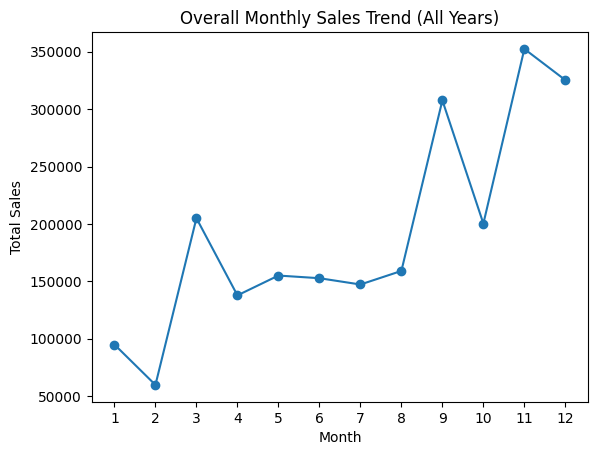

In [4]:
# Monthly sales aggregated across all years
monthly_sales_all = df.groupby('Month')['Sales'].sum().reset_index()

plt.figure()
plt.plot(monthly_sales_all['Month'], monthly_sales_all['Sales'], marker='o')
plt.title('Overall Monthly Sales Trend (All Years)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(monthly_sales_all['Month'])
plt.show()


In [4]:
top_products = (
    df.groupby('Product Name', as_index=False)
      .agg(Total_Sales=('Sales', 'sum'))
      .sort_values(by='Total_Sales', ascending=False)
      .head(10)
)
top_products


,Product Name,Total_Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


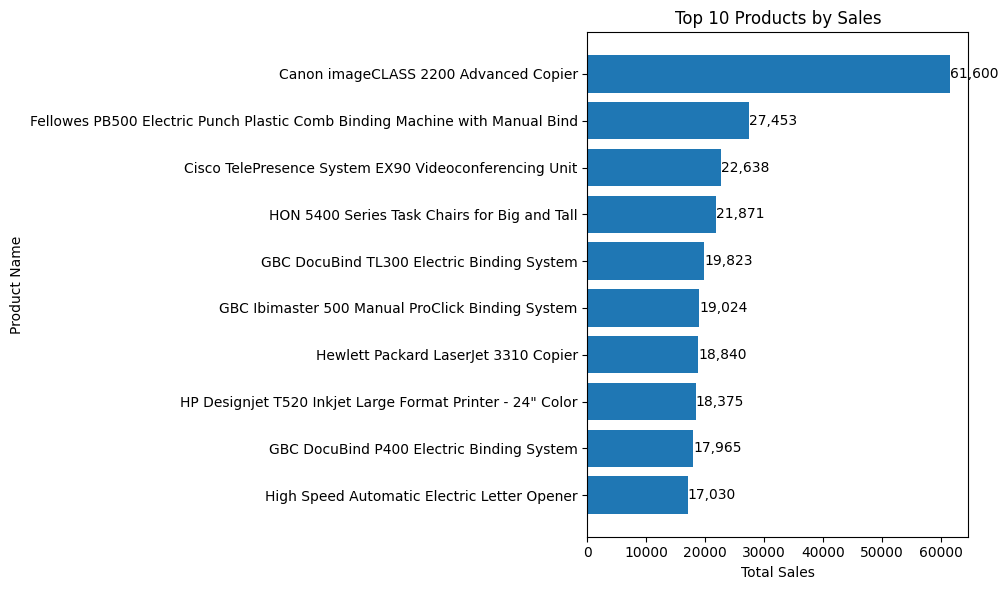

In [6]:
plt.figure(figsize=(10, 6))
plt.barh(top_products['Product Name'], top_products['Total_Sales'])
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()

# Add exact sales values on bars
for index, value in enumerate(top_products['Total_Sales']):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.tight_layout()
plt.show()


In [5]:
top_products_by_profit = (
    df.groupby('Product Name' , as_index=False)
      .agg(Profit=('Profit', 'sum'))
        .sort_values(by='Profit', ascending=False)
        .head(10)
)

print(top_products_by_profit)


                                           Product Name      Profit
404               Canon imageCLASS 2200 Advanced Copier  25199.9280
650   Fellowes PB500 Electric Punch Plastic Comb Bin...   7753.0390
805                Hewlett Packard LaserJet 3310 Copier   6983.8836
400                  Canon PC1060 Personal Laser Copier   4570.9347
787   HP Designjet T520 Inkjet Large Format Printer ...   4094.9766
165                   Ativa V4110MDD Micro-Cut Shredder   3772.9461
19     3D Systems Cube Printer, 2nd Generation, Magenta   3717.9714
1276  Plantronics Savi W720 Multi-Device Wireless He...   3696.2820
895                Ibico EPK-21 Electric Binding System   3345.2823
1840                  Zebra ZM400 Thermal Label Printer   3343.5360


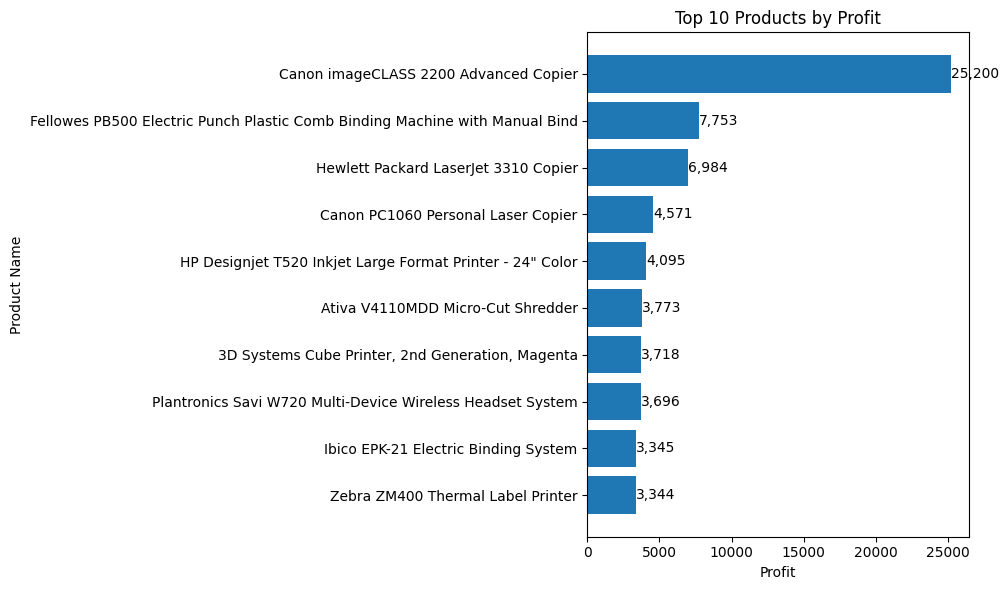

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(top_products_by_profit['Product Name'], top_products_by_profit['Profit'])
plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()

# Add exact sales values on bars
for index, value in enumerate(top_products_by_profit['Profit']):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.tight_layout()
plt.show()


In [6]:
category_performance = (
    df.groupby('Category', as_index=False)
      .agg(
          Total_Sales=('Sales', 'sum'),
          Total_Profit=('Profit', 'sum')
      )
)

category_performance


,Category,Total_Sales,Total_Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


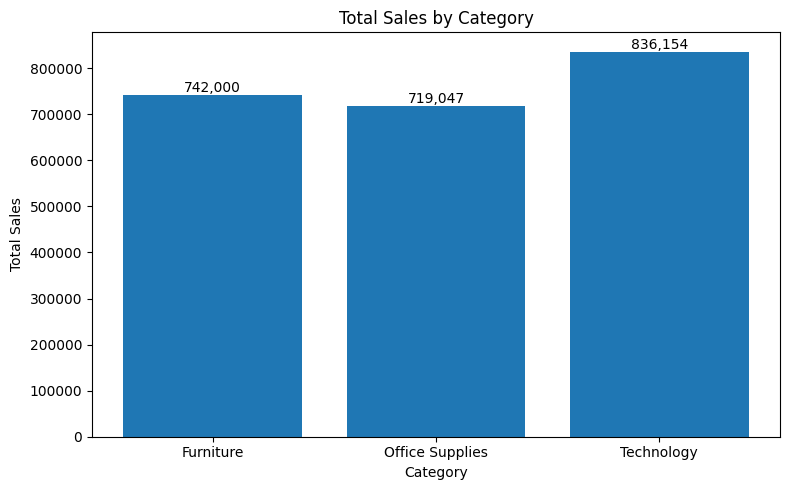

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(category_performance['Category'], category_performance['Total_Sales'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

# Add value labels on top of bars
for index, value in enumerate(category_performance['Total_Sales']):
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


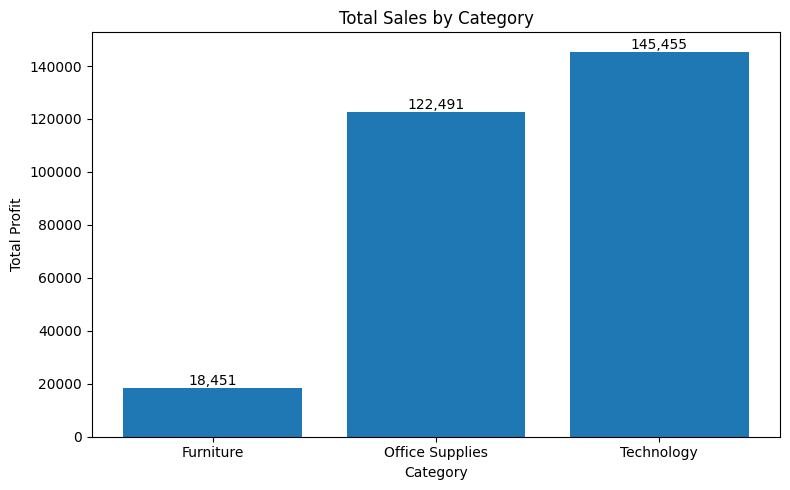

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(category_performance['Category'], category_performance['Total_Profit'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

# Add value labels on top of bars
for index, value in enumerate(category_performance['Total_Profit']):
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [7]:
sub_category_performance = (
    df.groupby('Sub-Category', as_index=False)
      .agg(
          Total_Sales=('Sales', 'sum'),
          Total_Profit=('Profit', 'sum')
      )
      .sort_values(by='Total_Sales', ascending=False)
)

sub_category_performance


,Sub-Category,Total_Sales,Total_Profit
13,Phones,330007.0540,44515.7306
5,Chairs,328449.1030,26590.1663
14,Storage,223843.6080,21278.8264
16,Tables,206965.5320,-17725.4811
3,Binders,203412.7330,30221.7633
11,Machines,189238.6310,3384.7569
0,Accessories,167380.3180,41936.6357
6,Copiers,149528.0300,55617.8249
4,Bookcases,114879.9963,-3472.5560
1,Appliances,107532.1610,18138.0054


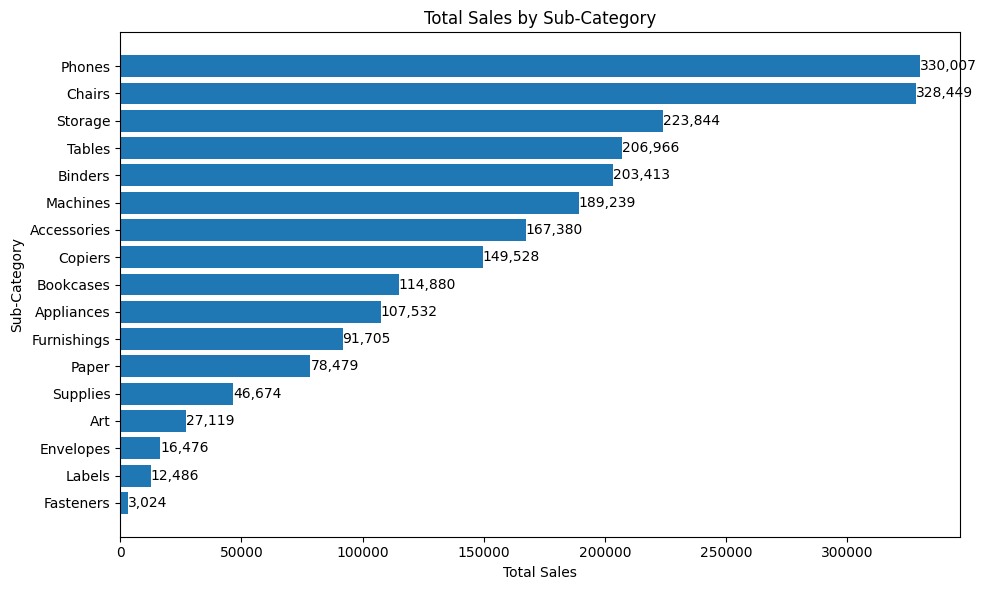

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(
    sub_category_performance['Sub-Category'],
    sub_category_performance['Total_Sales']
)
plt.title('Total Sales by Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.gca().invert_yaxis()

# Add value labels correctly for barh
for index, value in enumerate(sub_category_performance['Total_Sales']):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.tight_layout()
plt.show()


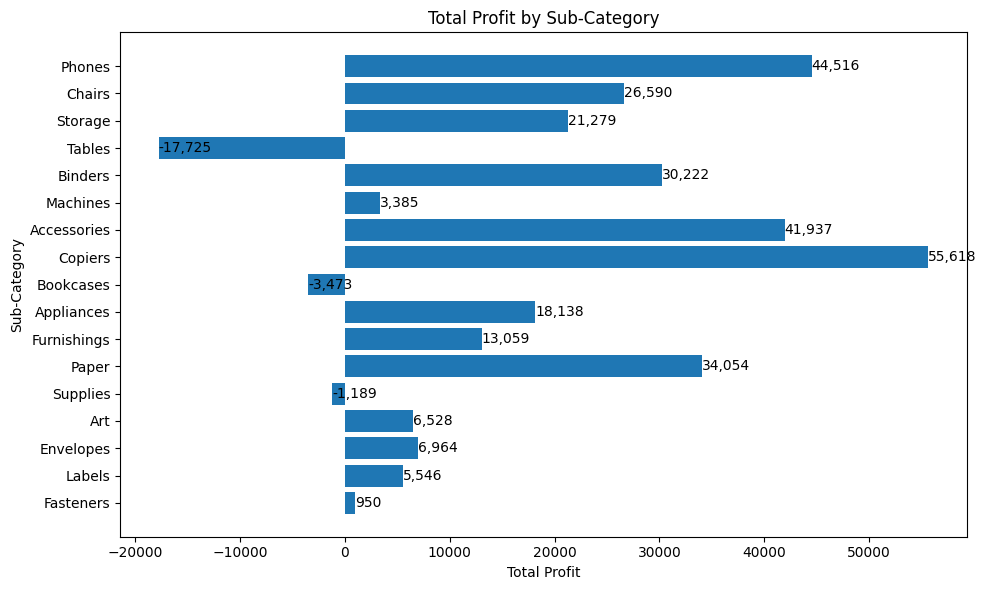

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(
    sub_category_performance['Sub-Category'],
    sub_category_performance['Total_Profit']
)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.gca().invert_yaxis()

# Add value labels correctly for barh
for index, value in enumerate(sub_category_performance['Total_Profit']):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.tight_layout()
plt.show()


In [9]:
region_performance = (
    df.groupby('Region', as_index=False)
      .agg(
          Total_Sales=('Sales', 'sum'),
          Total_Profit=('Profit', 'sum')
      )
)

region_performance


,Region,Total_Sales,Total_Profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


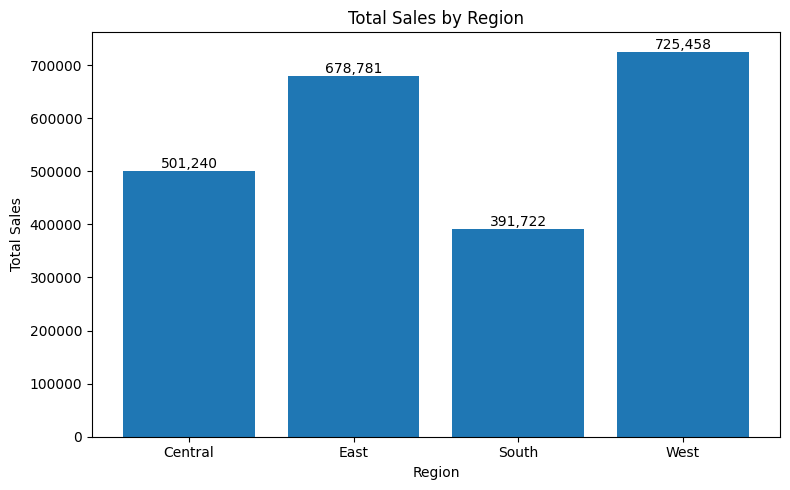

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(region_performance['Region'], region_performance['Total_Sales'])
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

# Add value labels on top of bars
for index, value in enumerate(region_performance['Total_Sales']):
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


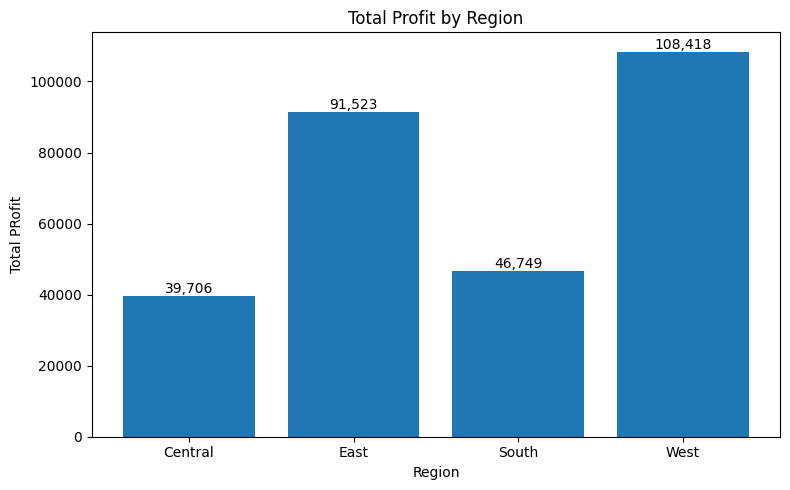

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(region_performance['Region'], region_performance['Total_Profit'])
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total PRofit')

# Add value labels on top of bars
for index, value in enumerate(region_performance['Total_Profit']):
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [18]:
df.to_csv('../data/superstore_sales_enhanced.csv', index=False)


MODEL PERFORMANCE
R2 Score: -0.0478
MAE: 25.98
RMSE: 225.39


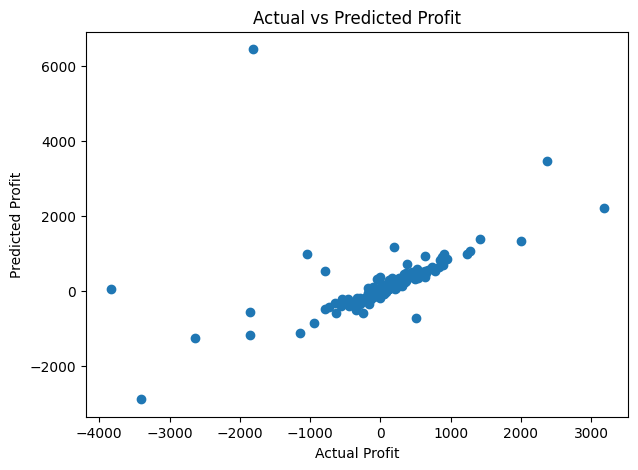


FUTURE PREDICTION
Predicted Profit for 2026 Furniture Product: $505.02


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_csv(
    "../data/superstore_sales.csv",
    encoding="latin1"
)

# -----------------------------
# DATE PROCESSING
# -----------------------------
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

# Extract time features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

# -----------------------------
# SELECT FEATURES
# -----------------------------
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Year",
    "Month",
    "Category",
    "Sub-Category",
    "Region",
    "Segment"
]

target = "Profit"

X = df[features]
y = df[target]

# -----------------------------
# ONE-HOT ENCODING
# -----------------------------
X = pd.get_dummies(
    X,
    drop_first=True
)

# Save feature names
feature_columns = X.columns

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# RANDOM FOREST MODEL
# -----------------------------
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# MODEL ACCURACY
# -----------------------------
y_pred = model.predict(X_test)

print("\nMODEL PERFORMANCE")
print(
    "R2 Score:",
    round(
        r2_score(
            y_test,
            y_pred
        ),
        4
    )
)

print(
    "MAE:",
    round(
        mean_absolute_error(
            y_test,
            y_pred
        ),
        2
    )
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print(
    "RMSE:",
    round(rmse, 2)
)

# -----------------------------
# VISUALIZATION
# -----------------------------
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

# -----------------------------
# FUTURE PREDICTION
# -----------------------------
# Example future input

future_data = pd.DataFrame({
    "Sales": [3000],
    "Quantity": [4],
    "Discount": [0.15],
    "Year": [2026],
    "Month": [8],
    "Category": ["Furniture"],
    "Sub-Category": ["Chairs"],
    "Region": ["South"],
    "Segment": ["Consumer"]
})

# Convert categorical data
future_data_encoded = pd.get_dummies(
    future_data
)

# Match training columns
future_data_encoded = future_data_encoded.reindex(
    columns=feature_columns,
    fill_value=0
)

# Predict
future_profit = model.predict(
    future_data_encoded
)

print("\nFUTURE PREDICTION")

print(
    f"Predicted Profit for 2026 "
    f"Furniture Product: "
    f"${future_profit[0]:.2f}"
)